In [2]:

import multiprocessing
from sko.GA import GA
from sko.tools import set_run_mode
from IPython.display import clear_output

import random
import Bio
import itertools
from Bio.Seq import Seq
import json
import numpy as np
import pandas as pd
import os 
import datetime
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from functools import lru_cache
from types import MethodType, FunctionType
import matplotlib.pyplot as plt
import warnings
import sys



In [3]:
aa2codon_dict = {
    "A" : ["GCT", "GCA", "GCC", "GCG"],
    "C" : ["TGT", "TGC"],
    "D" : ["GAC", "GAT"],
    "E" : ["GAG", "GAA"],
    "F" : ["TTC", "TTT"],
    "G" : ["GGA", "GGG", "GGT", "GGC"],
    "H" : ["CAC", "CAT"],
    #"I" : ["ATA", "ATC", "ATT"],
    "I" : ["ATC", "ATT"],
    "K" : ["AAG", "AAA"],
    "L" : ["CTC", "CTT", "TTG", "TTA", "CTG"],
    "M" : ["ATG"],
    "N" : ["AAT", "AAC"],
    "P" : ["CCC", "CCT", "CCA", "CCG"],
    "Q" : ["CAA", "CAG"],
    "R" : ["CGG", "CGC", "CGT"],
    "S" : ["TCG", "TCA", "TCC", "AGT", "TCT", "AGC"],
    "T" : ["ACA", "ACT", "ACG", "ACC"],
    "V" : ["GTA", "GTC", "GTT", "GTG"],
    "W" : ["TGG"],
    "Y" : ["TAC", "TAT"],
    "X" : ["TGCATGATCTACGTGCGTCACATGCAGTAC", "CACTAGCTCAGATTCAGTAGACCGCTGTTG", "TAGTAATGCAGACACTTGCGGTCCATCTCG", "AGCTGTCAGCACTACTAACTTGCGGTCAGT"]
    
}

In [4]:
cap_dict = {
    "cap_A": "TGCATGATCTACGTGCGTCACATGCAGTAC",
    "cap_B": "CACTAGCTCAGATTCAGTAGACCGCTGTTG",
    "cap_C": "TAGTAATGCAGACACTTGCGGTCCATCTCG",
    "cap_D": "AGCTGTCAGCACTACTAACTTGCGGTCAGT",
    
}

In [5]:
registration_dict = {
    "Sap1"   : "GCTCTTC",
    "BamH1"  : "GGATCC",
    "Age1"   : "ACCGGT",
    "EcoR1"  : "GAATTC",
    "Hind3"  : "AAGCTT",
    "Xho1"   : "CTCGAG",
    "Xba1"   : "TCTAGA",
    "Not1"   : "GCGGCCGC",
    "Kpn1"   : "GGTACC",
    "Nco1"   : "CCATGG",
    "Nde1"   : "CATATG",
    "Nhe1"   : "GCTAGC",
    "Sal1"   : "GTCGAC",
    "Age1"   : "ACCGGT",
    'Sac1'   : 'GAGCTC',   

}

registration_dict = {

    "Hind3"  : "AAGCTT",
    'Sac1'   : 'GAGCTC', 
    'BsrGI'  : 'TGTACA',

}

In [6]:
DARPin_2m22 = str("DLGKKLLEAARVGQDDEVRILMANGADVNAYDTIGSTPLHLAAYHGHLEIVEVLLKNGADVNANDLFGDTPLHLAAYSGHLEIVEVLLKYGADVNAQDKFGKTAFDISIDNGNEDLAEILQKLN")


protein_dict = {
    "1A1" :  "G" + "KRKRKRKR" + "GGGGSGGGGS" + DARPin_2m22 + "GSGS",
    "1A2" :  "GSGS" + "KRKRKRKR" + "GGGGSGGGGS" + DARPin_2m22 + "GSGS",
    "1A3" :  "GSGS" + "KRKRKRKR" + "GGGSGGGS" + DARPin_2m22 + "GSGS",
    "1B1" :  "GSGS" + "KRKRKRKR" + "GGSGGS" + DARPin_2m22 + "GSGS",
    "1B2" :  "GSGS" + "KRKRKRKR" + "GSGS" + DARPin_2m22 + "GSGS",
    "1B3" :  "GSGS" + "KRKRKRKR" + "GS" + DARPin_2m22 + "GSGS",
    "2A1" :  "GSGS" + DARPin_2m22 + "GGGGSGGGGS" + "KRKRKRKR" + "",
    "2A2" :  "GSGS" + DARPin_2m22 + "GGGGSGGGGS" + "KRKRKRKR" + "GSGS",
    "2A3" :  "GSGS" + DARPin_2m22 + "GGGSGGGS" + "KRKRKRKR" + "GSGS",
    "2B1" :  "GSGS" + DARPin_2m22 + "GGSGGS" + "KRKRKRKR" + "GSGS",
    "2B2" :  "GSGS" + DARPin_2m22 + "GSGS" + "KRKRKRKR" + "GSGS",
    "2B3" :  "GSGS" + DARPin_2m22 + "GS" + "KRKRKRKR" + "GSGS",
    "GB1": "YKLILNGKTLKGETTTEAVDAATAEKVFKQYANDNGVDGEWTYDDATKTFTVTE",\
    "EGFP":"MVSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTLVTTLTYGVQCFSRYPDHMKQHDFFKSAMPEGYVQERTIFFKDDGNYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNYNSHNVYIMADKQKNGIKVNFKIRHNIEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSTQSALSKDPNEKRDHMVLLEFVTAAGITLGMDELYK",\
    "mCherry":"MVSKGEEDNMAIIKEFMRFKVHMEGSVNGHEFEIEGEGEGRPYEGTQTAKLKVTKGGPLPFAWDILSPQFMYGSKAYVKHPADIPDYLKLSFPEGFKWERVMNFEDGGVVTVTQDSSLQDGEFIYKVKLRGTNFPSDGPVMQKKTMGWEASSERMYPEDGALKGEIKQRLKLKDGGHYDAEVKTTYKAKKPVQLPGAYNVNIKLDITSHNEDYTIVEQYERAEGRHSTGGMDELYK",\
    "2m22":"SDLGKKLLEAARVGQDDEVRILMANGADVNAYDTIGSTPLHLAAYHGHLEIVEVLLKNGADVNANDLFGDTPLHLAAYSGHLEIVEVLLKYGADVNAQDKFGKTAFDISIDNGNEDLAEILQKLN",\
    "3G61":"SDLGKKLLEAARAGQDDEVRILMANGADVNALDEVGWTPLHLAAWGHLEIVEVLLKNGADVNAADIDGYTPLHLAAFSGHLEIVEVLLKYGADVNADDQAGFTPLHLAAIFGHLEIVEVLLKNGADVNAQDKFGKTAFDISIDNGNEDLAEILQKLN",\
    "ccAn4":"GEIAALEQEIAALEKENAALEWEIAALEQG",\
    "ccBn4":"GKIAALKQKIAALKYKNAALKKKIAALKQG",\
    "TEV":"ENLYFQG",\
    "3C":"LEVLFQGP",\
    "FactorX": "IEGR",\
    "HisTag": "HHHHHH",\
    "KR4": "KRKRKRKR",\
    "SUMO": "HINLKVAGQDGSVVQFKIKHTPLSKLMKAYCERQGLSMRQIRFRFDGQPINETDTPAQLEMEDEDTIDVFQ",\
    "BSA": "MKWVTFISLLLLFSSAYSRGVFRRDTHKSEIAHRFKDLGEEHFKGLVLIAFSQYLQQCPFDEHVKLVNELTEFAKTCVADESHAGCEKSLHTLFGDELCKVASLRETYGDMADCCEKQEPERNECFLSHKDDSPDLPKLKPDPNTLCDEFKADEKKFWGKYLYEIARRHPYFYAPELLYYANKYNGVFQECCQAEDKGACLLPKIETMREKVLASSARQRLRCASIQKFGERALKAWSVARLSQKFPKAEFVEVTKLVTDLTKVHKECCHGDLLECADDRADLAKYICDNQDTISSKLKECCDKPLLEKSHCIAEVEKDAIPENLPPLTADFAEDKDVCKNYQEAKDAFLGSFLYEYSRRHPEYAVSVLLRLAKEYEATLEECCAKDDPHACYSTVFDKLKHLVDEPQNLIKQNCDQFEKLGEYGFQNALIVRYTRKVPQVSTPTLVEVSRSLGKVGTRCCTKPESERMPCTEDYLSLILNRLCVLHEKTPVSEKVTKCCTESLVNRRPCFSALTPDETYVPKAFDEKLFTFHADICTLPDTEKQIKKQTALVELLKHKPKATEEQLKTVMENFVAFVDKCCAADDKEACFAVEGPKLVVSTQTALA",\
    "2m22_TEV" : "GGGGSDLGKKLLEAARVGQDDEVRILMANGADVNAYDTIGSTPLHLAAYHGHLEIVEVLLKNGADVNANDLFGDTPLHLAAYSGHLEIVEVLLKYGADVNAQDKFGKTAFDISIDNGNEDLAEILQKLNGGGENLYFQ",\
    "KR7_GS_2m22" : "GSGS" + "KRKRKRKRKRKRKR" + "GS" + DARPin_2m22 + "GGG" + "ENLYFQ",\
    "2m22_GS_KR7" : "GGGGS" + DARPin_2m22 + "GS" + "KRKRKRKRKRKRKR" + "GSGS" + "ENLYFQ",\

    "Na4_N_termianl_cap" : "PDLPKLVKLLKSSNEEILLKALRALAEIASGG",\
    "M_internal_module": "NEQIQAVIDAGALPALVQLLSSPNEQILQEALWALSNIASGG",\
    "Q2_internal_module": "NEQIQAVIDAGALPALVQLLSSPNEQILQEALWALSNIAGGPTPLWRAEQIQAVIDAGALPALVQLLSSPNEQILQEALWALSNIASGG",\
    "A_C_terminal_cap": "NEQKQAVKEAGALEKLEQLQSHENEKIQKEAQEALEKLQSH",\

    "DARPin_N_cap" : "GSDLGKKLLEAARAGQDDEVRILMANGADVNA", \
    "DARPin_C_cap" : "QDKFGKTAFDISIDNGNEDLAEILQKLN", \
    "DARPin_3G61": "LDEVGWTPLHLAAWGHLEIVEVLLKNGADVNAADIDGYTPLHLAAFSGHLEIVEVLLKYGADVNADDQAGFTPLHLAAIFGHLEIVEVLLKNGADVNA", \
    "DARPin_2blank" : "GDSSGGTPLHLAASGGHLEIVEVLLKYGADVNAGDSSGGTPLHLAASGGHLEIVEVLLKNGADVNA", \
    
    "DARPin_3G124": "ADDVGVTPLHLAAQRGHLEIVEVLLKYGADVNAADLWGQTPLHLAATAGHLEIVEVLLKNGADVNARDNIGHTPLHLAAWAGHLEIVEVLLKYGADVNA", \
    "DARPin_3G124_C" : "QDKFGKTPFDLAIDNGNEDIAEVLQKAA", \

    'DAPRin_dArmRP_binder_v1':'RDQKGHTPLHLAATNGHLEIVEVLLKYGADVNAPDRQGQTPLHLAAHHGHLEIVEVLLKNGADVNAQDSRGHTPLHLAAFSGHLEIVEVLLKYGADVNAKDRYGRTPLHLAAAQGHLEIVEVLLKNGADVNARDYQGQTPLHLAADRGHLEIVEVLLKYGADVNAQDRHGQTPLHLAAKQGHLEIVEVLLKNGADVNATDRRGNTPLHLAAYRGHLEIVEVLLKYGADVNAQDRRGRTPLHLAAFRGHLEIVEVLLKNGADVNA',\


    "His_SUMO_pT1A": "MKHHHHHHPMSDYDIPTTENLYFQGAMGNDHINLKVAGQDGSVVQFKIKHTPLSKLMKAYCERQGLSMRQIRFRFDGQPINETDTPAQLEMEDEDTIDVFQQQTGGFNWRCCLIPACRRNHKKFC",\
    
    "KR7_2m22_KR7": "GSGS" + "KRKRKRKRKRKRKR" + "GGS" + DARPin_2m22 + "GS" + "KRKRKRKRKRKRKR" + "GSGS" + "ENLYFQ",\
    "KR7": "KRKRKRKRKRKRKR" ,\

    "KR7_3G61_KR7": "GSGSKRKRKRKRKRKRKRGGSDLGKKLLEAARAGQDDEVRILMANGADVNALDEVGWTPLHLAAWGHLEIVEVLLKNGADVNAADIDGYTPLHLAAFSGHLEIVEVLLKYGADVNADDQAGFTPLHLAAIFGHLEIVEVLLKNGADVNAQDKFGKTAFDISIDNGNEDLAEILQKLNGSKRKRKRKRKRKRKRGSGSENLYFQ" ,\
    
    
    "MBP": "KIEEGKLVIWINGDKGYNGLAEVGKKFEKDTGIKVTVEHPDKLEEKFPQVAATGDGPDIIFWAHDRFGGYAQSGLLAEITPDKAFQDKLYPFTWDAVRYNGKLIAYPIAVEALSLIYNKDLLPNPPKTWEEIPALDKELKAKGKSALMFNLQEPYFTWPLIAADGGYAFKYENGKYDIKDVGVDNAGAKAGLTFLVDLIKNKHMNADTDYSIAEAAFNKGETAMTINGPWAWSNIDTSKVNYGVTVLPTFKGQPSKPFVGVLSAGINAASPNKELAKEFLENYLLTDEGLEAVNKDKPLGAVALKSYAEVLAKDPRIAATMENAQKGEIMPNIPQMSAFWYAVRTAVINAASGRQTVDEALKDAQT",\

}

In [7]:

#print(protein_dict["2m22_GS_KR7"])
protein_dict["mCherry_His"] = "GSSGEFYKLG" + protein_dict["mCherry"] + "AAASSG" + protein_dict["HisTag"]

protein_dict["His_GB1_EGFP_TEV"] = "MRGS" + protein_dict["HisTag"] + "SSG" + protein_dict["FactorX"] + \
                                    "SSG" + protein_dict["GB1"] + "GGGGS" + protein_dict["EGFP"] + \
                                    "GGGGS" + protein_dict["TEV"][0:-1]


protein_dict["Na4M4A"] = protein_dict["Na4_N_termianl_cap"] + protein_dict["M_internal_module"]*4 + protein_dict["A_C_terminal_cap"]
protein_dict["Na4M5A"] = protein_dict["Na4_N_termianl_cap"] + protein_dict["M_internal_module"]*5 + protein_dict["A_C_terminal_cap"]
protein_dict["Na4M6A"] = protein_dict["Na4_N_termianl_cap"] + protein_dict["M_internal_module"]*6 + protein_dict["A_C_terminal_cap"]
protein_dict["Na4M7A"] = protein_dict["Na4_N_termianl_cap"] + protein_dict["M_internal_module"]*7 + protein_dict["A_C_terminal_cap"]

protein_dict["Na4M7A_v2"] = "G" + protein_dict["Na4M7A"] + "GGG" + protein_dict["TEV"][0:-1]
protein_dict["Na4M6A_v2"] = "G" + protein_dict["Na4M6A"] + "GGG" + protein_dict["TEV"][0:-1]
protein_dict["Na4M5A_v2"] = "G" + protein_dict["Na4M5A"] + "GGG" + protein_dict["TEV"][0:-1]
protein_dict["Na4M4A_v2"] = "G" + protein_dict["Na4M4A"] + "GGG" + protein_dict["TEV"][0:-1]

protein_dict["ccAn4_Na4M7A_v2"] = protein_dict["ccAn4"] + "SGSGSG" + protein_dict["Na4M7A"] + "GGG" + protein_dict["TEV"][0:-1]
protein_dict["ccAn4_Na4M6A_v2"] = protein_dict["ccAn4"] + "SGSGSG" + protein_dict["Na4M6A"] + "GGG" + protein_dict["TEV"][0:-1]
protein_dict["ccAn4_Na4M5A_v2"] = protein_dict["ccAn4"] + "SGSGSG" + protein_dict["Na4M5A"] + "GGG" + protein_dict["TEV"][0:-1]
protein_dict["ccAn4_Na4M4A_v2"] = protein_dict["ccAn4"] + "SGSGSG" + protein_dict["Na4M4A"] + "GGG" + protein_dict["TEV"][0:-1]

protein_dict["Na4M7A_ccBn4_v2"] = "G" + protein_dict["Na4M7A"] + "GSGSGS" + protein_dict["ccBn4"] + "GG" + protein_dict["TEV"][0:-1]
protein_dict["Na4M6A_ccBn4_v2"] = "G" + protein_dict["Na4M6A"] + "GSGSGS" + protein_dict["ccBn4"] + "GG" + protein_dict["TEV"][0:-1]
protein_dict["Na4M5A_ccBn4_v2"] = "G" + protein_dict["Na4M5A"] + "GSGSGS" + protein_dict["ccBn4"] + "GG" + protein_dict["TEV"][0:-1]
protein_dict["Na4M4A_ccBn4_v2"] = "G" + protein_dict["Na4M4A"] + "GSGSGS" + protein_dict["ccBn4"] + "GG" + protein_dict["TEV"][0:-1]
protein_dict["KR7_3G61_KR7 + 2* Na4M7A"] = protein_dict["KR7_3G61_KR7"] + protein_dict["Na4M7A_v2"] + protein_dict["Na4M7A_v2"]
protein_dict["_6_protein_complex_2m22"] = protein_dict["KR7_2m22_KR7"]*2 + protein_dict["ccAn4_Na4M7A_v2"]*2 + protein_dict["Na4M7A_ccBn4_v2"]*2


protein_dict["Na4Q2A"] = protein_dict["Na4_N_termianl_cap"] + protein_dict["Q2_internal_module"] + protein_dict["A_C_terminal_cap"]
protein_dict["Na4Q3A"] = protein_dict["Na4_N_termianl_cap"] + 'A'+ protein_dict["M_internal_module"][1:]+ protein_dict["Q2_internal_module"] + protein_dict["A_C_terminal_cap"]
protein_dict["Na4Q4A"] = protein_dict["Na4_N_termianl_cap"] + protein_dict["Q2_internal_module"]*2 + protein_dict["A_C_terminal_cap"]
protein_dict["Na4Q5A"] = protein_dict["Na4_N_termianl_cap"] + 'A'+ protein_dict["M_internal_module"][1:]+ protein_dict["Q2_internal_module"]*2 + protein_dict["A_C_terminal_cap"]
protein_dict["Na4Q6A"] = protein_dict["Na4_N_termianl_cap"] + protein_dict["Q2_internal_module"]*3 + protein_dict["A_C_terminal_cap"]

protein_dict["Na4Q6M3"]    = protein_dict["Na4_N_termianl_cap"] + protein_dict["Q2_internal_module"]*3 + protein_dict["M_internal_module"]*3                           + 'G' + protein_dict["3C"][0:-2]
protein_dict["Na4Q6M2H12"] = protein_dict["Na4_N_termianl_cap"] + protein_dict["Q2_internal_module"]*3 + protein_dict["M_internal_module"]*2 + 'NEQIQAVIDAGALPALVQLLS' + 'G' + protein_dict["3C"][0:-2]

protein_dict["M3Q6A"]    = 'G' +                          protein_dict["M_internal_module"]*3 + protein_dict["Q2_internal_module"]*3 + 'GGG' + protein_dict["3C"][0:-2]
protein_dict["H3M3Q6A"]  = 'G' + "PNEQILQEALWALSNIASGG" + protein_dict["M_internal_module"]*3 + protein_dict["Q2_internal_module"]*3 + 'GGG' + protein_dict["3C"][0:-2]

protein_dict["ccBn4_Na4Q6A"] =       protein_dict["ccBn4"] + "GSGSGSG" + protein_dict["Na4Q6A"]+ "GGG" + protein_dict["3C"][0:-2]
protein_dict["Na4Q6A_ccBn4"] = "G" + protein_dict["Na4Q6A"]+ "GSGSGSG" + protein_dict["ccBn4"] + "GGG" + protein_dict["TEV"][0:-1]

protein_dict["3G61_ARQR3"] = 'G' + protein_dict["3G61"] + 'GS' + 'ARQR'*3 + 'GSGS' + protein_dict["TEV"][0:-1]

protein_dict["6_complex_by_chimera_dArmRP"] = protein_dict["Na4Q6M2H12"] + protein_dict["H3M3Q6A"] + protein_dict["3G61_ARQR3"]*2 + protein_dict["EGFP"]*2 + 'KR'*6


protein_dict["6_complex_without_KR"] = protein_dict["Na4Q6M2H12"] + protein_dict["H3M3Q6A"] + protein_dict["3G61_ARQR3"]*2 + protein_dict["EGFP"]*2

protein_dict["HMQ_ternary_complex"] = protein_dict["H3M3Q6A"] + protein_dict["3G61_ARQR3"] + protein_dict["EGFP"]

protein_dict["QMH_ternary_complex"] = protein_dict["Na4Q6M2H12"] + protein_dict["3G61_ARQR3"] + protein_dict["EGFP"]

protein_dict["EGFP__3G61_ARQR3"] = protein_dict["3G61_ARQR3"] + protein_dict["EGFP"]

protein_dict["5_complex_by_chimera_dArmRP"] = protein_dict["Na4Q6M2H12"] + protein_dict["H3M3Q6A"] + protein_dict["3G61_ARQR3"]*2 + protein_dict["EGFP"] + 'KR'*6


protein_dict["QMH_HMQ_DARPin_KR6"] = protein_dict["Na4Q6M2H12"] + protein_dict["H3M3Q6A"] + protein_dict["3G61_ARQR3"]*2  + 'KR'*6

protein_dict["QMH_DARPin"] = protein_dict["Na4Q6M2H12"] + protein_dict["3G61_ARQR3"]
protein_dict["HMQ_DARPin"] = protein_dict["H3M3Q6A"] + protein_dict["3G61_ARQR3"]
protein_dict["QMH_HMQ_KR6"] = protein_dict["Na4Q6M2H12"] + protein_dict["H3M3Q6A"]  + 'KR'*6

protein_dict["Na4Q6M6Q6A"]    = 'G'+protein_dict["Na4_N_termianl_cap"] + protein_dict["Q2_internal_module"]*3 + protein_dict["M_internal_module"]*6 + protein_dict["Q2_internal_module"]*3 + protein_dict["A_C_terminal_cap"]+ 'GGG' + protein_dict["3C"][0:-2]
protein_dict["Na4Q6M6Q6A"]    = protein_dict["Na4_N_termianl_cap"] + protein_dict["Q2_internal_module"]*3 + protein_dict["M_internal_module"]*6 + protein_dict["Q2_internal_module"]*3 + protein_dict["A_C_terminal_cap"]

protein_dict["Na4M6A_3C"] = protein_dict["Na4M6A"] + 'GGG' + protein_dict["3C"][0:-2]

protein_dict["Na4Q6M6Q6A_MBP"]    = 'G'+protein_dict["Na4_N_termianl_cap"] + protein_dict["Q2_internal_module"]*3 + protein_dict["M_internal_module"]*6 + protein_dict["Q2_internal_module"]*3 + protein_dict["A_C_terminal_cap"] + 'GGGGS' + protein_dict["MBP"] + 'GGS'  + protein_dict["3C"][0:-2]
protein_dict["Na4Q6M6Q6M6Q6A"]    = 'G'+protein_dict["Na4_N_termianl_cap"] + protein_dict["Q2_internal_module"]*3 + protein_dict["M_internal_module"]*6 + protein_dict["Q2_internal_module"]*3 + protein_dict["M_internal_module"]*6 + protein_dict["Q2_internal_module"]*3 + protein_dict["A_C_terminal_cap"] + 'GGG'  + protein_dict["3C"][0:-2]

protein_dict["3G61_8blank_ARQR3"]    = protein_dict["DARPin_N_cap"] + protein_dict["DARPin_3G61"] + protein_dict["DARPin_2blank"]*4 + protein_dict["DARPin_C_cap"]+ 'GS' + 'ARQR'*3 + 'GSGS' + protein_dict["TEV"][0:-1]
protein_dict["3G61_6blank_ARQR3"]    = protein_dict["DARPin_N_cap"] + protein_dict["DARPin_3G61"] + protein_dict["DARPin_2blank"]*3 + protein_dict["DARPin_C_cap"]+ 'GS' + 'ARQR'*3 + 'GSGS' + protein_dict["TEV"][0:-1]
protein_dict["3G61_4blank_ARQR3"]    = protein_dict["DARPin_N_cap"] + protein_dict["DARPin_3G61"] + protein_dict["DARPin_2blank"]*2 + protein_dict["DARPin_C_cap"]+ 'GS' + 'ARQR'*3 + 'GSGS' + protein_dict["TEV"][0:-1]
protein_dict["3G61_2blank_ARQR3"]    = protein_dict["DARPin_N_cap"] + protein_dict["DARPin_3G61"] + protein_dict["DARPin_2blank"]*1 + protein_dict["DARPin_C_cap"]+ 'GS' + 'ARQR'*3 + 'GSGS' + protein_dict["TEV"][0:-1]

protein_dict["ARQR3_linker_3G61"]    = 'G'+ 'ARQR'*3 + 'GGGGS'*2 + protein_dict["DARPin_N_cap"] + protein_dict["DARPin_3G61"] + protein_dict["DARPin_C_cap"]+'GSGS' + protein_dict["TEV"][0:-1]


protein_dict["EGFP_NOflu"] = "MVSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTLVTTLVQCFSRYPDHMKQHDFFKSAMPEGYVQERTIFFKDDGNYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNYNSHNVYIMADKQKNGIKVNFKIRHNIEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSTQSALSKDPNEKRDHMVLLEFVTAAGITLGMDELYK"


protein_dict["Na4M42A"]    = 'G'+protein_dict["Na4_N_termianl_cap"] + protein_dict["Q2_internal_module"]*3 + (protein_dict["M_internal_module"]*6 + protein_dict["Q2_internal_module"]*3)*3 + protein_dict["A_C_terminal_cap"] + 'GGG'  + protein_dict["3C"][0:-2]
protein_dict["Na4M54A"]    = 'G'+protein_dict["Na4_N_termianl_cap"] + protein_dict["Q2_internal_module"]*3 + (protein_dict["M_internal_module"]*6 + protein_dict["Q2_internal_module"]*3)*4 + protein_dict["A_C_terminal_cap"] + 'GGG'  + protein_dict["3C"][0:-2]
protein_dict["Na4M66A"]    = 'G'+protein_dict["Na4_N_termianl_cap"] + protein_dict["Q2_internal_module"]*3 + (protein_dict["M_internal_module"]*6 + protein_dict["Q2_internal_module"]*3)*5 + protein_dict["A_C_terminal_cap"] + 'GGG'  + protein_dict["3C"][0:-2]
protein_dict["Na4M78A"]    = 'G'+protein_dict["Na4_N_termianl_cap"] + protein_dict["Q2_internal_module"]*3 + (protein_dict["M_internal_module"]*6 + protein_dict["Q2_internal_module"]*3)*6 + protein_dict["A_C_terminal_cap"] + 'GGG'  + protein_dict["3C"][0:-2]
protein_dict["Na4M90A"]    = 'G'+protein_dict["Na4_N_termianl_cap"] + protein_dict["Q2_internal_module"]*3 + (protein_dict["M_internal_module"]*6 + protein_dict["Q2_internal_module"]*3)*7 + protein_dict["A_C_terminal_cap"] + 'GGG'  + protein_dict["3C"][0:-2]
protein_dict["Na4M102A"]    = 'G'+protein_dict["Na4_N_termianl_cap"] + protein_dict["Q2_internal_module"]*3 + (protein_dict["M_internal_module"]*6 + protein_dict["Q2_internal_module"]*3)*8 + protein_dict["A_C_terminal_cap"] + 'GGG'  + protein_dict["3C"][0:-2]
protein_dict["Na4M114A"]    = 'G'+protein_dict["Na4_N_termianl_cap"] + protein_dict["Q2_internal_module"]*3 + (protein_dict["M_internal_module"]*6 + protein_dict["Q2_internal_module"]*3)*9 + protein_dict["A_C_terminal_cap"] + 'GGG'  + protein_dict["3C"][0:-2]
protein_dict["Na4M126A"]    = 'G'+protein_dict["Na4_N_termianl_cap"] + protein_dict["Q2_internal_module"]*3 + (protein_dict["M_internal_module"]*6 + protein_dict["Q2_internal_module"]*3)*10 + protein_dict["A_C_terminal_cap"] + 'GGG'  + protein_dict["3C"][0:-2]
protein_dict["Na4M138A"]    = 'G'+protein_dict["Na4_N_termianl_cap"] + protein_dict["Q2_internal_module"]*3 + (protein_dict["M_internal_module"]*6 + protein_dict["Q2_internal_module"]*3)*11 + protein_dict["A_C_terminal_cap"] + 'GGG'  + protein_dict["3C"][0:-2]
protein_dict["Na4M150A"]    = 'G'+protein_dict["Na4_N_termianl_cap"] + protein_dict["Q2_internal_module"]*3 + (protein_dict["M_internal_module"]*6 + protein_dict["Q2_internal_module"]*3)*12 + protein_dict["A_C_terminal_cap"] + 'GGG'  + protein_dict["3C"][0:-2]
protein_dict["Na4M162A"]    = 'G'+protein_dict["Na4_N_termianl_cap"] + protein_dict["Q2_internal_module"]*3 + (protein_dict["M_internal_module"]*6 + protein_dict["Q2_internal_module"]*3)*13 + protein_dict["A_C_terminal_cap"] + 'GGG'  + protein_dict["3C"][0:-2]
protein_dict["Na4M174A"]    = 'G'+protein_dict["Na4_N_termianl_cap"] + protein_dict["Q2_internal_module"]*3 + (protein_dict["M_internal_module"]*6 + protein_dict["Q2_internal_module"]*3)*14 + protein_dict["A_C_terminal_cap"] + 'GGG'  + protein_dict["3C"][0:-2]
protein_dict["Na4M186A"]    = 'G'+protein_dict["Na4_N_termianl_cap"] + protein_dict["Q2_internal_module"]*3 + (protein_dict["M_internal_module"]*6 + protein_dict["Q2_internal_module"]*3)*15 + protein_dict["A_C_terminal_cap"] + 'GGG'  + protein_dict["3C"][0:-2]
protein_dict["Na4M198A"]    = 'G'+protein_dict["Na4_N_termianl_cap"] + protein_dict["Q2_internal_module"]*3 + (protein_dict["M_internal_module"]*6 + protein_dict["Q2_internal_module"]*3)*16 + protein_dict["A_C_terminal_cap"] + 'GGG'  + protein_dict["3C"][0:-2]
protein_dict["Na4M210A"]    = 'G'+protein_dict["Na4_N_termianl_cap"] + protein_dict["Q2_internal_module"]*3 + (protein_dict["M_internal_module"]*6 + protein_dict["Q2_internal_module"]*3)*17 + protein_dict["A_C_terminal_cap"] + 'GGG'  + protein_dict["3C"][0:-2]
protein_dict["Na4M222A"]    = 'G'+protein_dict["Na4_N_termianl_cap"] + protein_dict["Q2_internal_module"]*3 + (protein_dict["M_internal_module"]*6 + protein_dict["Q2_internal_module"]*3)*18 + protein_dict["A_C_terminal_cap"] + 'GGG'  + protein_dict["3C"][0:-2]
protein_dict["Na4M234A"]    = 'G'+protein_dict["Na4_N_termianl_cap"] + protein_dict["Q2_internal_module"]*3 + (protein_dict["M_internal_module"]*6 + protein_dict["Q2_internal_module"]*3)*19 + protein_dict["A_C_terminal_cap"] + 'GGG'  + protein_dict["3C"][0:-2]
protein_dict["Na4M246A"]    = 'G'+protein_dict["Na4_N_termianl_cap"] + protein_dict["Q2_internal_module"]*3 + (protein_dict["M_internal_module"]*6 + protein_dict["Q2_internal_module"]*3)*20 + protein_dict["A_C_terminal_cap"] + 'GGG'  + protein_dict["3C"][0:-2]
protein_dict["Na4M258A"]    = 'G'+protein_dict["Na4_N_termianl_cap"] + protein_dict["Q2_internal_module"]*3 + (protein_dict["M_internal_module"]*6 + protein_dict["Q2_internal_module"]*3)*21 + protein_dict["A_C_terminal_cap"] + 'GGG'  + protein_dict["3C"][0:-2]
protein_dict["Na4M270A"]    = 'G'+protein_dict["Na4_N_termianl_cap"] + protein_dict["Q2_internal_module"]*3 + (protein_dict["M_internal_module"]*6 + protein_dict["Q2_internal_module"]*3)*22 + protein_dict["A_C_terminal_cap"] + 'GGG'  + protein_dict["3C"][0:-2]


In [8]:

protein_dict["c_fusion"]    = 'QDKFGKTPLHLAADNGHLEIVEVLLKYGADVNA'

protein_dict["H02"]    = 'GADVSAQDKFGKTPGDLAGDNGNEWIAKKLLLAAAREGHREAVERAIKAGADVNA'#6 aa overlap with one repeat before #5LE3
protein_dict["H06"]    = 'GADVFAQDKFGKTPFDLARDNGNEWIAKLLLAAALLEAARQGQRDRVEKLMANGADVNA'#6 aa overlap with one repeat before #5LEB
protein_dict["H09"]    = 'GADVSAQDKFGKTPRDLARDNGNEWIWKLLLDALKYLLLEAAREGHRDRVEKLIKAGADVNA'#6 aa overlap with one repeat before #5LE6
protein_dict["H11"]    = 'GALVKAKDKFGKTPKDLARDNGNQFIYELLEKAELLEKLLLEAAREGHRDRVEEFIKRGADVNA'#6 aa overlap with one repeat before #5LE4
protein_dict["H12"]    = 'GAAVGAQDKFGKTPKDLARDNGNQWIYELLEKAEKDLRRKLLEAARAGHREEVEKLIKLGADVNA'#6 aa overlap with one repeat before #5LEA
protein_dict["H13"]    = 'GADVNAQDKFGKTPEDLAKDNGNQWIAQKLEEAKKEDLDRKLLEAARAGHRDEVEDLIKNGADVNA'#6 aa overlap with one repeat before #5LE7
protein_dict["H14"]    = 'GADVEAQDKFGKTPEDLAKDNGNQWIAQKLEEAKKKKDLDEKLLEAARAGHRDEVEDLIKNGADVNA'#6 aa overlap with one repeat before #No crystal structure!
protein_dict["H15"]    = 'GADVRAQDKFGKTPKDLARDNGNEWIRELLEKAERKLKDLDRKLLEAARAGHRDEVEDLIKNGADVNA'#6 aa overlap with one repeat before #5LE8

protein_dict["3G61_H02_8B_ARQR3"]    = protein_dict["DARPin_N_cap"] + protein_dict["DARPin_3G61"] + protein_dict["c_fusion"][0:-6] + protein_dict["H02"] + protein_dict["DARPin_2blank"]*4 + protein_dict["DARPin_C_cap"]+ 'GS' + 'ARQR'*3 + 'GSGS' + protein_dict["TEV"][0:-1]
protein_dict["3G61_H11_8B_ARQR3"]    = protein_dict["DARPin_N_cap"] + protein_dict["DARPin_3G61"] + protein_dict["c_fusion"][0:-6] + protein_dict["H11"] + protein_dict["DARPin_2blank"]*4 + protein_dict["DARPin_C_cap"]+ 'GS' + 'ARQR'*3 + 'GSGS' + protein_dict["TEV"][0:-1]
protein_dict["3G61_H12_8B_ARQR3"]    = protein_dict["DARPin_N_cap"] + protein_dict["DARPin_3G61"] + protein_dict["c_fusion"][0:-6] + protein_dict["H12"] + protein_dict["DARPin_2blank"]*4 + protein_dict["DARPin_C_cap"]+ 'GS' + 'ARQR'*3 + 'GSGS' + protein_dict["TEV"][0:-1]
protein_dict["3G61_H15_8B_ARQR3"]    = protein_dict["DARPin_N_cap"] + protein_dict["DARPin_3G61"] + protein_dict["c_fusion"][0:-6] + protein_dict["H15"] + protein_dict["DARPin_2blank"]*4 + protein_dict["DARPin_C_cap"]+ 'GS' + 'ARQR'*3 + 'GSGS' + protein_dict["TEV"][0:-1]


protein_dict["3G61_H02_6B_ARQR3"]    = protein_dict["DARPin_N_cap"] + protein_dict["DARPin_3G61"] + protein_dict["c_fusion"][0:-6] + protein_dict["H02"] + protein_dict["DARPin_2blank"]*3 + protein_dict["DARPin_C_cap"]+ 'GS' + 'ARQR'*3 + 'GSGS' + protein_dict["TEV"][0:-1]
protein_dict["3G61_H11_6B_ARQR3"]    = protein_dict["DARPin_N_cap"] + protein_dict["DARPin_3G61"] + protein_dict["c_fusion"][0:-6] + protein_dict["H11"] + protein_dict["DARPin_2blank"]*3 + protein_dict["DARPin_C_cap"]+ 'GS' + 'ARQR'*3 + 'GSGS' + protein_dict["TEV"][0:-1]
protein_dict["3G61_H12_6B_ARQR3"]    = protein_dict["DARPin_N_cap"] + protein_dict["DARPin_3G61"] + protein_dict["c_fusion"][0:-6] + protein_dict["H12"] + protein_dict["DARPin_2blank"]*3 + protein_dict["DARPin_C_cap"]+ 'GS' + 'ARQR'*3 + 'GSGS' + protein_dict["TEV"][0:-1]
protein_dict["3G61_H15_6B_ARQR3"]    = protein_dict["DARPin_N_cap"] + protein_dict["DARPin_3G61"] + protein_dict["c_fusion"][0:-6] + protein_dict["H15"] + protein_dict["DARPin_2blank"]*3 + protein_dict["DARPin_C_cap"]+ 'GS' + 'ARQR'*3 + 'GSGS' + protein_dict["TEV"][0:-1]



protein_dict["3G61_H02_4B_ARQR3"]    = protein_dict["DARPin_N_cap"] + protein_dict["DARPin_3G61"] + protein_dict["c_fusion"][0:-6] + protein_dict["H02"] + protein_dict["DARPin_2blank"]*2 + protein_dict["DARPin_C_cap"]+ 'GS' + 'ARQR'*3 + 'GSGS' + protein_dict["TEV"][0:-1]
protein_dict["3G61_H11_4B_ARQR3"]    = protein_dict["DARPin_N_cap"] + protein_dict["DARPin_3G61"] + protein_dict["c_fusion"][0:-6] + protein_dict["H11"] + protein_dict["DARPin_2blank"]*2 + protein_dict["DARPin_C_cap"]+ 'GS' + 'ARQR'*3 + 'GSGS' + protein_dict["TEV"][0:-1]
protein_dict["3G61_H12_4B_ARQR3"]    = protein_dict["DARPin_N_cap"] + protein_dict["DARPin_3G61"] + protein_dict["c_fusion"][0:-6] + protein_dict["H12"] + protein_dict["DARPin_2blank"]*2 + protein_dict["DARPin_C_cap"]+ 'GS' + 'ARQR'*3 + 'GSGS' + protein_dict["TEV"][0:-1]
protein_dict["3G61_H15_4B_ARQR3"]    = protein_dict["DARPin_N_cap"] + protein_dict["DARPin_3G61"] + protein_dict["c_fusion"][0:-6] + protein_dict["H15"] + protein_dict["DARPin_2blank"]*2 + protein_dict["DARPin_C_cap"]+ 'GS' + 'ARQR'*3 + 'GSGS' + protein_dict["TEV"][0:-1]



protein_dict["3G61_H02_2B_ARQR3"]    = protein_dict["DARPin_N_cap"] + protein_dict["DARPin_3G61"] + protein_dict["c_fusion"][0:-6] + protein_dict["H02"] + protein_dict["DARPin_2blank"]*1 + protein_dict["DARPin_C_cap"]+ 'GS' + 'ARQR'*3 + 'GSGS' + protein_dict["TEV"][0:-1]
protein_dict["3G61_H11_2B_ARQR3"]    = protein_dict["DARPin_N_cap"] + protein_dict["DARPin_3G61"] + protein_dict["c_fusion"][0:-6] + protein_dict["H11"] + protein_dict["DARPin_2blank"]*1 + protein_dict["DARPin_C_cap"]+ 'GS' + 'ARQR'*3 + 'GSGS' + protein_dict["TEV"][0:-1]
protein_dict["3G61_H12_2B_ARQR3"]    = protein_dict["DARPin_N_cap"] + protein_dict["DARPin_3G61"] + protein_dict["c_fusion"][0:-6] + protein_dict["H12"] + protein_dict["DARPin_2blank"]*1 + protein_dict["DARPin_C_cap"]+ 'GS' + 'ARQR'*3 + 'GSGS' + protein_dict["TEV"][0:-1]
protein_dict["3G61_H15_2B_ARQR3"]    = protein_dict["DARPin_N_cap"] + protein_dict["DARPin_3G61"] + protein_dict["c_fusion"][0:-6] + protein_dict["H15"] + protein_dict["DARPin_2blank"]*1 + protein_dict["DARPin_C_cap"]+ 'GS' + 'ARQR'*3 + 'GSGS' + protein_dict["TEV"][0:-1]




protein_dict["4B_H02_3G61"]    = protein_dict["DARPin_N_cap"] + (protein_dict["DARPin_2blank"]*2)[0:-6] + protein_dict["H02"] + protein_dict["DARPin_3G61"] + protein_dict["DARPin_C_cap"]
protein_dict["4B_H06_3G61"]    = protein_dict["DARPin_N_cap"] + (protein_dict["DARPin_2blank"]*2)[0:-6] + protein_dict["H06"] + protein_dict["DARPin_3G61"] + protein_dict["DARPin_C_cap"]
protein_dict["4B_H09_3G61"]    = protein_dict["DARPin_N_cap"] + (protein_dict["DARPin_2blank"]*2)[0:-6] + protein_dict["H09"] + protein_dict["DARPin_3G61"] + protein_dict["DARPin_C_cap"]
protein_dict["4B_H11_3G61"]    = protein_dict["DARPin_N_cap"] + (protein_dict["DARPin_2blank"]*2)[0:-6] + protein_dict["H11"] + protein_dict["DARPin_3G61"] + protein_dict["DARPin_C_cap"]
protein_dict["4B_H12_3G61"]    = protein_dict["DARPin_N_cap"] + (protein_dict["DARPin_2blank"]*2)[0:-6] + protein_dict["H12"] + protein_dict["DARPin_3G61"] + protein_dict["DARPin_C_cap"]
protein_dict["4B_H13_3G61"]    = protein_dict["DARPin_N_cap"] + (protein_dict["DARPin_2blank"]*2)[0:-6] + protein_dict["H13"] + protein_dict["DARPin_3G61"] + protein_dict["DARPin_C_cap"]
protein_dict["4B_H14_3G61"]    = protein_dict["DARPin_N_cap"] + (protein_dict["DARPin_2blank"]*2)[0:-6] + protein_dict["H14"] + protein_dict["DARPin_3G61"] + protein_dict["DARPin_C_cap"]
protein_dict["4B_H15_3G61"]    = protein_dict["DARPin_N_cap"] + (protein_dict["DARPin_2blank"]*2)[0:-6] + protein_dict["H15"] + protein_dict["DARPin_3G61"] + protein_dict["DARPin_C_cap"]

protein_dict["DARPin_4B"]    = protein_dict["DARPin_N_cap"] + (protein_dict["DARPin_2blank"]*2) + protein_dict["DARPin_C_cap"]


protein_dict["ARQR3_GGS_6B_3G124"]              = 'GS'+'ARQR'*3+'GGS' + protein_dict["DARPin_N_cap"] + (protein_dict["DARPin_2blank"]*3)                                   + protein_dict["DARPin_3G124"] + protein_dict["DARPin_3G124_C"] + 'GSGS' + protein_dict["TEV"]+'SSG'
protein_dict["ARQR3_GGS_6B_H11_3G124"]          = 'GS'+'ARQR'*3+'GGS' + protein_dict["DARPin_N_cap"] + (protein_dict["DARPin_2blank"]*3)[0:-6]       + protein_dict["H11"] + protein_dict["DARPin_3G124"] + protein_dict["DARPin_3G124_C"] + 'GSGS' + protein_dict["TEV"]+'SSG'
protein_dict["ARQR3_GGS_8Bbinder_H11_3G61"]    = 'GS'+'ARQR'*3+'GGS' + protein_dict["DARPin_N_cap"] + protein_dict["DAPRin_dArmRP_binder_v1"][0:-6] + protein_dict["H11"] + protein_dict["DARPin_3G124"] + protein_dict["DARPin_3G124_C"] + 'GSGS' + protein_dict["TEV"]+'SSG'


protein_dict["3G124_H11_6B_ARQR3"]              = protein_dict["DARPin_N_cap"][2:] + protein_dict["DARPin_3G124"][0:-6] + protein_dict["H11"] + protein_dict["DARPin_2blank"]*3 + protein_dict["DARPin_C_cap"]+ 'GS' + 'ARQR'*3 + 'GSGS' + protein_dict["TEV"]+'SSG'


In [9]:

def random_back_translate(input_aa):
    output_seq = ""

    for aa in input_aa:
        #print(aa)
        output_seq = output_seq + random.choice(aa2codon_dict[aa])

    #print(output_seq)

    #output_seq_rc = Seq(output_seq).reverse_complement()
    #str=output_seq + output_seq_rc

    output_seq=output_seq

    return (output_seq)

In [10]:
def longestRepeatedSubstring(output_seq): 
  
    n = len(output_seq) 
    LCSRe = [[0 for x in range(n + 1)]  
                for y in range(n + 1)] 
  
    res = "" # To store result 
    res_length = 0 # To store length of result 
  
    # building table in bottom-up manner 
    index = 0
    for i in range(1, n + 1): 
        for j in range(i + 1, n + 1): 
              
            # (j-i) > LCSRe[i-1][j-1] to remove 
            # overlapping 
            if (output_seq[i - 1] == output_seq[j - 1] and
                LCSRe[i - 1][j - 1] < (j - i)): 
                LCSRe[i][j] = LCSRe[i - 1][j - 1] + 1
  
                # updating maximum length of the 
                # substring and updating the finishing 
                # index of the suffix 
                if (LCSRe[i][j] > res_length): 
                    res_length = LCSRe[i][j] 
                    index = max(i, index) 
                  
            else: 
                LCSRe[i][j] = 0
  
    # If we have non-empty result, then insert  
    # all characters from first character to  
    # last character of string 
    if (res_length > 0): 
        for i in range(index - res_length + 1, 
                                    index + 1): 
            res = res + output_seq[i - 1] 
  
    return res 


In [11]:
def get_high_GC_frag_num(output_seq, n=20):
    
    n_bp_list =[]
    
    high_GC_frag_num = 0 

    for i in range(len(output_seq)-n):
        n_bp_list.append(output_seq[i:i+n])
    
    for n_bp_frag in n_bp_list:
    
        if (n_bp_frag.count('G') + n_bp_frag.count('C'))/len(n_bp_frag) > 0.9:
            high_GC_frag_num =+ 1


    return high_GC_frag_num

In [12]:
def get_GC_68percent_frag_num(output_seq, n=60):
    
    n_bp_list =[]
    
    high_GC_frag_num = 0 

    for i in range(len(output_seq)-n):
        n_bp_list.append(output_seq[i:i+n])
    
    for n_bp_frag in n_bp_list:
    
        if (n_bp_frag.count('G') + n_bp_frag.count('C'))/len(n_bp_frag) > 0.68:
            high_GC_frag_num =+ 1


    return high_GC_frag_num

In [13]:
def get_hairpin_num(output_seq, n=10):
    
    n_bp_list =[]
    rc_list = []

    for i in range(len(output_seq)-n):
        n_bp_list.append(output_seq[i:i+n])
    
    for n_bp_frag in list(set(n_bp_list)):
        rc_frag = str(Seq(n_bp_frag).reverse_complement())
        rc_list.append(rc_frag)
    
    hairpin_num = len(set(n_bp_list)) + len(set(rc_list)) - len(set(n_bp_list + rc_list))
        
        
    return hairpin_num

In [14]:
def n_bp_num(n, output_seq):
    n = int(n)
    n_bp_list =[]

    for i in range(len(output_seq)-n):
        n_bp_list.append(output_seq[i:i+n])
    
    output_num = len(n_bp_list) - len(set(n_bp_list))

    return output_num

In [15]:
def sizeof_fmt(num, suffix='B'):
    ''' by Fred Cirera,  https://stackoverflow.com/a/1094933/1870254, modified'''
    for unit in ['','Ki','Mi','Gi','Ti','Pi','Ei','Zi']:
        if abs(num) < 1024.0:
            return "%3.1f %s%s" % (num, unit, suffix)
        num /= 1024.0
    return "%.1f %s%s" % (num, 'Yi', suffix)

In [16]:
def reverse_translate(p):
    
    output_seq = ""

    for i in range(len(p)):
        #print(aa)
        codon_num = int(p[i]%len(aa2codon_dict[input_seq[i]]))
        append_codon = aa2codon_dict[input_seq[i]][codon_num]
        output_seq = output_seq + append_codon
        #print(p[i], input_seq[i], int(p[i]%len(aa2codon_dict[input_seq[i]])), aa2codon_dict[input_seq[i]], append_codon)
        
    return output_seq

In [17]:
def schaffer(p):
    '''
    
    '''
    """
    output_seq = ""

    for i in range(len(p)):
        #print(aa)
        codon_num = int(p[i]%len(aa2codon_dict[input_seq[i]]))
        append_codon = aa2codon_dict[input_seq[i]][codon_num]
        output_seq = output_seq + append_codon
        #print(p[i], input_seq[i], int(p[i]%len(aa2codon_dict[input_seq[i]])), aa2codon_dict[input_seq[i]], append_codon)
    
    #print(output_seq)
    """
    #output_seq_rc = Seq(output_seq).reverse_complement()
    #str=output_seq + output_seq_rc
    output_seq_apo = reverse_translate(p)
    #_8mer_rate = _8_bp_repeat_rate(output_seq)
    #_9mer_rate = _9_bp_repeat_rate(output_seq)
    
    
    output_seq_holo = seq_before_insert + rest_sequence_n + output_seq_apo+ rest_sequence_c + seq_after_insert
    
    sequence_score = 0
    
    
    # Score that reflect synthesis complex, decrease to ensure IDT can synthesis it.
    for i in [8, 13]:
        sequence_score += n_bp_num(i, output_seq_apo)
    
    
    # Score that reflect the cloning difficulty after assemble to the reat part of ArmRP
    # Reduce this score can make sure follwoing PCR primer have unique binding site
    
    for i in [14]:
        sequence_score += n_bp_num(i, output_seq_holo)*0.05
    
    
    # Bouns score for extra registraction enzyme site
    
    registration_dict = {
        "Hind3"  : "AAGCTT",
        'Sac1'   : 'GAGCTC', 
        'BsrG1'  : 'TGTACA',}
    for site in registration_dict.values():
        if site in output_seq_apo:
            sequence_score += 0.1
    
    # Bouns score for extrame GC content, time costing step
    sequence_score += 0.02*get_high_GC_frag_num(output_seq_apo)
    sequence_score += 0.02*get_GC_68percent_frag_num(output_seq_apo)
    
    
    # Bouns score for haripin, time costing step
    sequence_score += 0.02*get_hairpin_num(output_seq_holo)
    
    
    return sequence_score

In [18]:
nowTime=datetime.datetime.now().strftime('%Y_%m_%d_%H_%M')

In [19]:
seq_name = 'DARPin_N+_3G61_I+_D_b_Ccap+_D_b_N+_D_b_Y+_D_b_N'

seq_name = 'BamHI_3G61_Cfusion_H12_NheI'



seq_name = "ARQR3_GGS_6B_3G61"
seq_name = "ARQR3_GGS_6B_H11_3G61"
seq_name = "ARQR3_GGS_8Bbinder_H11_3G61"
seq_name = "3G124_H11_6B_ARQR3"

protein_dict["M"] = protein_dict["M_internal_module"] 
protein_dict['Na4'] = protein_dict["Na4_N_termianl_cap"]
protein_dict['A'] = protein_dict["A_C_terminal_cap"]
protein_dict['Q2'] = protein_dict["Q2_internal_module"]


protein_dict['G5'] = ''.join(["NEQIQAVIDAGALPALVQLLSSPNEQILQEALWALSNIASGG", \
                              "NEQIQAVIDAGALPALVQLLSSPNEQILQEALWALSNIASGG", \
                              "NEQIQAVIDAGALPALVQLLSSPNEQILQEALWALSNIAIRGAWAVAFFG", \
                              "YEQIQAVIDAGALPALVQLLSSPNEQILQEALWALSNIASGG", \
                              "NEQIQAVIDAGALPALVQLLSSPNEQILQEALWALSNIASGG"]) 

    
protein_dict["ARQRKRKRARQR_GGS_6B_H11_2m22"] = protein_dict["TEV"]+'GSGS'+'ARQRKRKRARQR'+'GGS' + protein_dict["DARPin_N_cap"] + (protein_dict["DARPin_2blank"]*3)[0:-6]       + protein_dict["H11"] + protein_dict["2m22"] + 'GSGS' + protein_dict["TEV"]+'GSGSGSHHHHHH'

protein_dict["ARQR3_GGS_8B_H11_3G124"]          = protein_dict["TEV"]+'GSGS'+'ARQR'*3+'GGS' + protein_dict["DARPin_N_cap"] + (protein_dict["DARPin_2blank"]*4)[0:-6]       + protein_dict["H11"] + protein_dict["DARPin_3G124"] + protein_dict["DARPin_3G124_C"] + 'GSGS' + protein_dict["TEV"][:-1]


seq_name = "Na4" +'+M'*6 + "+A"
seq_name = "M" +'+M'*11

seq_name = "M" +'+M'*3 +'+G5' +'+M'*3
seq_name = "Q2" +'+Q2'*2 +'+M'*27 +'+Q2'+'+M'*2+'+Q2'


protein_dict["_000"] = protein_dict["M"]*12
protein_dict["_001"] = protein_dict["M"]*10+protein_dict["Q2"]
protein_dict["_010"] = protein_dict["M"]*8 +protein_dict["Q2"]+protein_dict["M"]*2
protein_dict["_011"] = protein_dict["M"]*8 +protein_dict["Q2"]*2
protein_dict["_100"] = protein_dict["M"]*6 +protein_dict["Q2"]+protein_dict["M"]*4
protein_dict["_101"] = protein_dict["M"]*6 +protein_dict["Q2"]+protein_dict["M"]*2+protein_dict["Q2"]
protein_dict["_110"] = protein_dict["M"]*6 +protein_dict["Q2"]*2+protein_dict["M"]*2
protein_dict["_111"] = protein_dict["M"]*6 +protein_dict["Q2"]*3
protein_dict["_0100_for8cargos"] = protein_dict["M"] +protein_dict["Q2"]+protein_dict["M"]*2
protein_dict["_1101_for8cargos"] = protein_dict["Q2"]*2 +protein_dict["M"]*2+protein_dict["Q2"]




seq_name = '_001'#+'+_010'+'+_011'+'+_100'+'+_101'+'+_110'+'+_111'
input_seq = ''.join([protein_dict[i] for i in seq_name.split("+")])
input_seq = input_seq[10:] + 'NEQIQAVIDAGALPALVQ'
#seq_name = "ARQRKRKRARQR_GGS_6B_H11_2m22"
#input_seq = protein_dict[seq_name]


"""
cc_A = 'QLEQELAALDQEIAALEQERAALEWQIQ'
cc_B = 'QLKQRLAALDQRIAALKQRRAALKWQIQ'
M = 'NEQIQAVIDAGALPALVQLLSSPNEQILQEALWALSNIASGG'
print(len(cc_A))
dArmRP_order_list={
    'dArmRP_ladder1_A': 'ENLYFQGSGS'+cc_A+'A'+ M*2+'NEQIQAVIDAGALPALVQLLSQQAQQQ'+cc_A+'GSGSENLYFQG',
    'dArmRP_ladder1_B': 'ENLYFQGSGS'+cc_B+'QDPLLLAQ'+M+'NEQIQAVIDAGALPALVQLLST'+cc_B+'GSGSENLYFQG',
    'dArmRP_ladder2_A': 'ENLYFQGSGS'+cc_A+'AQKEQAAAEAV'+M*3+'NEQIQAVIDAGALPALVQLLSKAAKLKEIQLRA'+cc_A+'GSGSENLYFQG',
    'dArmRP_ladder2_B': 'ENLYFQGSGS'+cc_B+'AKKLD'+M+'NEQIQAVIDAGALPALVQLLSQSLLSQE'+cc_B+'GSGSENLYFQG',
    'dArmRP_ladder3_A': 'ENLYFQGSGS'+cc_A+'DAQQKQQLPALVQLLSSPNEQILQEALWALSNIASGG'+ M*2+'NEQIQAVIDAGALPALVQLLSQQQLA'+cc_A+'GSGSENLYFQG',
    'dArmRP_ladder3_B': 'ENLYFQGSGS'+cc_B+'QIEAKQQAQAEKLPALVQLLSSPNEQILQEALWALSNIASGG'+M+'NEQIQAVIDAGALPALVQLLSDLQAQQQRQWEKQS'+cc_B+'GSGSENLYFQG',
}

seq_name = "dArmRP_ladder3_B"
input_seq = dArmRP_order_list[seq_name]

seq_name = "ARQR3_GGS_8B_H11_3G124"
input_seq = protein_dict[seq_name]
"""
seq_before_insert = 'CCCGACTTGCCAAAGTTGGTTAAACTTTTGAAGAGCAGCAATGAGGAGATTTTACTTAAGGCATTGCGCGCGCTCGCAGAAATCGCATCCGGCGGAAACGAGCAGATTCAAGCGGTAATTGATGCA'

seq_after_insert = 'GGAGCTCTACCAGCTCTTGTACAGCTCTTAAGCTCGCCGAACGAGCAAATCTTACAAGAAGCTTTATGGGCTCTTTCCAACATTGCTTCGGGTGGCAACGAGCAAATCCAAGCGGTCATCGACGCAGGAGCGTTACCAGCACTGGTTCAATTATTGTCGTCGCCAAACGAACAGATTTTGCAAGAGGCACTTTGGGCGCTGAGTAATATCGCCTCGGGCGGCAATGAGCAGATCCAGGCCGTTATCGACGCTGGCGCACTTCCCGCTCTCGTACAGTTGCTCTCTTCGCCTAATGAGCAAATCCTTCAAGAAGCTCTTTGGGCCTTATCGAACATCGCAAGTGGCGGGAACGAGCAGATCCAAGCCGTGATTGATGCAGGGGCCCTTCCAGCTTTGGTACAACTGCTCTCCAGCCCGAATGAGCAAATTCTTCAGGAAGCCCTGTGGGCTTTAAGCAATATCGCATCGGGAGGCAACGAACAGATCCAAGCTGTAATCGACGCGGGGGCGCTCCCGGCTTTAGTTCAACTCCTGTCCAGTCCAAATGAGCAGATTCTCCAAGAAGCCTTATGGGCACTGTCCAATATTGCATCCGGAGGTAATGAACAGATTCAGGCCGTAATCGATGCCGGCGCCCTCCCCGCACTTGTGCAATTGCTTTCGTCCCCAAACGAGCAGATCTTACAGGAGGCATTATGGGCCCTGTCAAACATCGCTAGTGGGGGAAATGAACAAATCCAGGCAGTCATCGATGCGGGTGCATTGCCCGCATTAGTACAGCTCCTTAGCTCCCCCAATGAGCAAATTTTACAGGAAGCACTGTGGGCCTTGTCTAATATTGCCTCAGGAGGGAATGAACAAATTCAGGCTGTTATTGACGCAGGCGCTCTGCCGGCCCTCGTCCAACTTTTATCATCGCCCAACGAGCAGATTTTACAAGAAGCATTGTGGGCGCTTAGTAACATCGCGTCAGGTGGGAACGAACAGATTCAAGCTGTCATTGACGCGGGAGCATTACCGGCCTTGGTCCAGTTATTATCGAGTCCTAATGAACAGATCCTCCAGGAGGCTTTATGGGCGTTATCTAACATTGCGTCTGGGGGTAACGAGCAAATTCAAGCGGTTATTGATGCCGGAGCACTCCCAGCTCTGGTGCAACTGTTGAGTTCACCCAATGAACAAATCTTGCAAGAAGCGCTCTGGGCACTCAGCAACATCGCCAGCGGCGGAAACGAGCAGATTCAGGCGGTGATTGACGCCGGTGCTTTACCAGCGCTTGTTCAGTTACTCAGTAGTCCCAACGAACAAATTTTGCAGGAGGCGTTGTGGGCATTGTCAAATATCGCGAGCGGAGGAAACGAACAAATCCAAGCAGTGATCGATGCTGGAGCGCTGCCTGCCTTAGTGCAGCTTTTAAGTAGCCCTAACGAACAAATTCTGCAGGAAGCGTTATGGGCTCTCTCGAATATTGCGAGTGGAGGTAATGAGCAGATTCAAGCAGTAATTGATGCTGGGGCTTTGCCTGCTCTCGTACAaCTCCTTTCATCGCCCAATGAGCAGATCCTTCAAGAAGCTCTTTGGGCGTTATCTAACATTGCCAGCGGGGGAAATGAGCAGAAGCAGGCCGTAAAGGAGGCGGGAGCCCTGGAGAAACTTGAGCAGTTACAAAGCCATGAAAACGAGAAAATTCAAAAGGAAGCGCAAGAGGCCCTTGAAAAACTTCAATCTCAC'



#rest_sequence_n = cap_dict['cap_A'] + 'GGATCC' # BamHI site
#rest_sequence_n = 'TCCATGGGC' # NcoI site

#rest_sequence_c = 'GAATTC'+ cap_dict['cap_A']# EcoRI site



#seq_before_insert = ''
#seq_after_insert = ''
#rest_sequence_n = 'GGATCC'# BamHI site
#rest_sequence_c = 'TAATAACTCGAG'# **+XhoI 
rest_sequence_n = ''
rest_sequence_c = ''

In [20]:
protein_dict["M"]

'NEQIQAVIDAGALPALVQLLSSPNEQILQEALWALSNIASGG'

                     Y_history:  5.5 MiB
                           _i7: 13.2 KiB
                  protein_dict:  9.1 KiB
                           _i8:  8.1 KiB
                           _ii:  5.8 KiB
                          _i19:  5.8 KiB
                           _i6:  5.1 KiB
                          _i21:  4.4 KiB
                            GA:  2.0 KiB
                          _i17:  1.9 KiB
GGGGCGCTTCCAGCGCTGGTACAGCTGTTGAGTAGTCCGAACGAACAAATTCTCCAAGAAGCTTTATGGGCCTTATCTAATATCGCTGGAGGCCCCACACCACTCTGGCGGGCAGAGCAGATTCAAGCTGTAATCGACGCAGGAGCCCTTCCGGCATTGGTCCAGTTACTGTCTTCACCCAATGAGCAGATTTTACAAGAAGCCCTCTGGGCATTGTCGAACATTGCTAGTGGAGGGAATGAACAAATTCAAGCGGTTATCGACGCCGGCGCATTGCCGGCTTTGGTTCAACTTTTAAGCTCGCCGAATGAGCAAATCCTTCAGGAGGCGCTCTGGGCGTTGTCAAATATTGCAGGAGGACCAACACCCTTATGGCGTGCCGAGCAGATTCAGGCGGTGATTGATGCCGGAGCTCTGCCCGCATTAGTTCAATTACTTAGTTCGCCAAATGAACAGATTCTTCAAGAAGCATTGTGGGCTCTCTCCAACATCGCGTCAGGTGGAAATGAGCAGATCCAAGCTGTCATCGATGCTGGTGCGTTACCTGCACTCGTACAATTGCTCAGTAGCCCCAACGAACAAATTTTGCA

Process ForkPoolWorker-20:
Process ForkPoolWorker-18:
Process ForkPoolWorker-24:
Process ForkPoolWorker-23:
Process ForkPoolWorker-21:
Process ForkPoolWorker-19:
Process ForkPoolWorker-17:
Process ForkPoolWorker-22:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/lib/python3.8/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
Traceback (most recent call last):
  File "/usr/lib/python3.8/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/lib/python3.8/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
  File "/usr/lib/python3.8/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/lib/python3.8/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/lib

KeyboardInterrupt: 

  File "/usr/lib/python3.8/multiprocessing/pool.py", line 125, in worker
    result = (True, func(*args, **kwds))
  File "/usr/lib/python3.8/multiprocessing/pool.py", line 125, in worker
    result = (True, func(*args, **kwds))
  File "/usr/lib/python3.8/multiprocessing/pool.py", line 48, in mapstar
    return list(map(*args))
  File "/usr/lib/python3.8/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/lib/python3.8/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/lib/python3.8/multiprocessing/pool.py", line 125, in worker
    result = (True, func(*args, **kwds))
  File "/usr/lib/python3.8/multiprocessing/pool.py", line 125, in worker
    result = (True, func(*args, **kwds))
  File "/usr/lib/python3.8/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
  File "/usr/lib/python3.8/multiprocessing/pool.py", line 48, in mapstar
    return list(map(*args))
  File "/

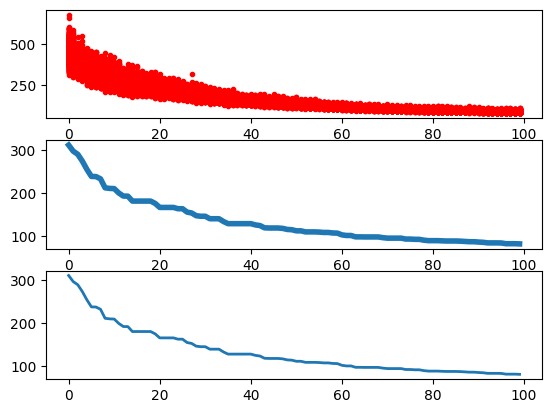

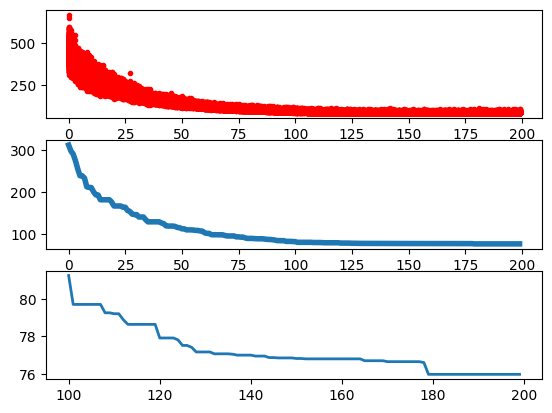

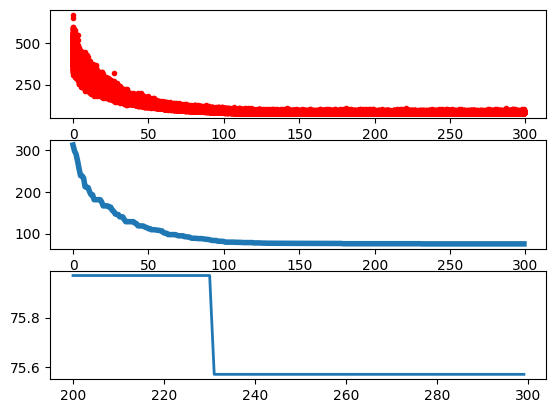

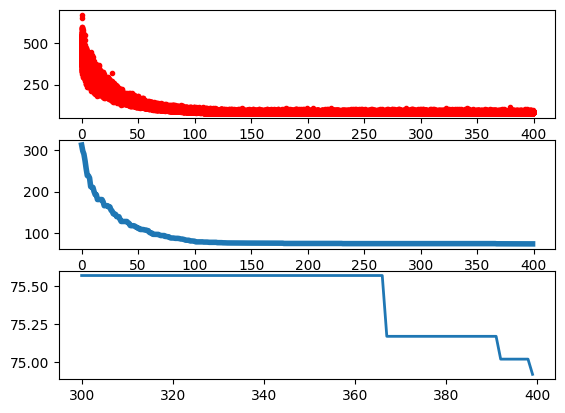

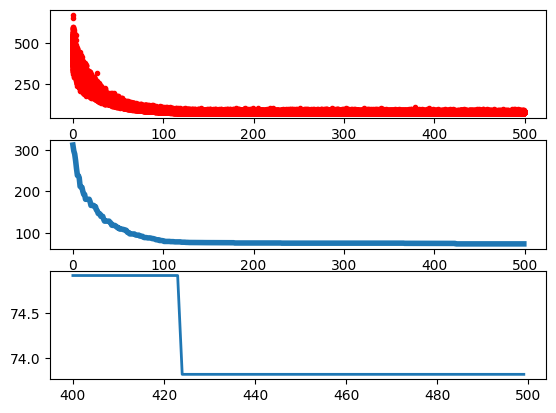

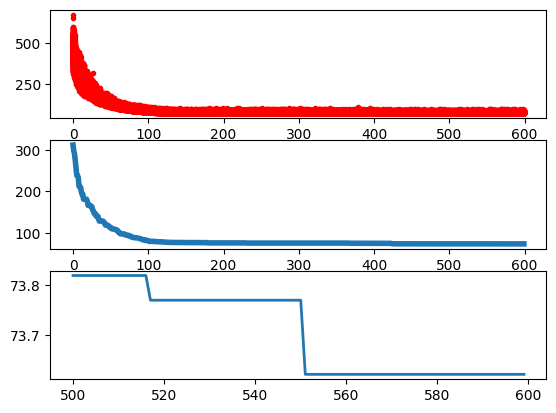

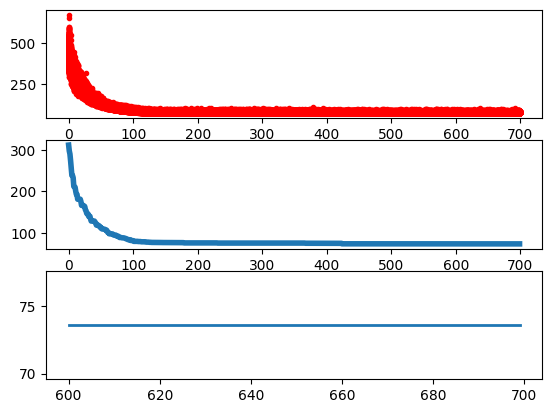

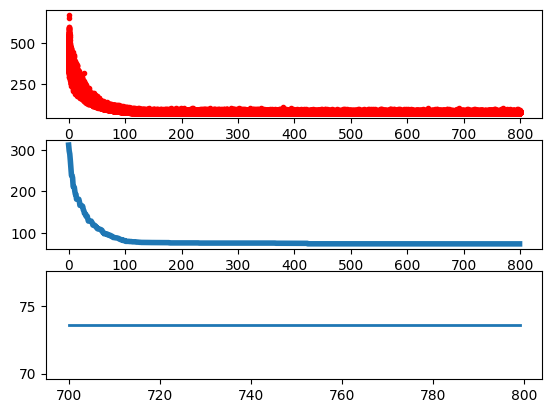

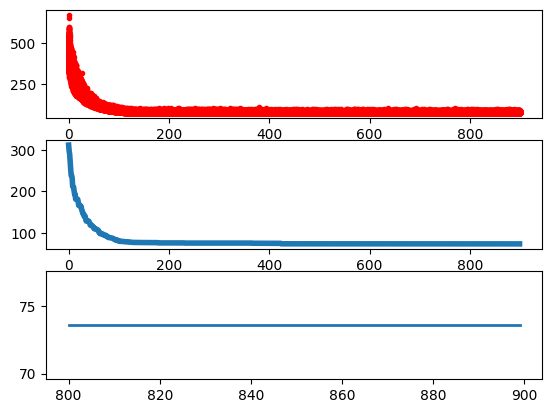

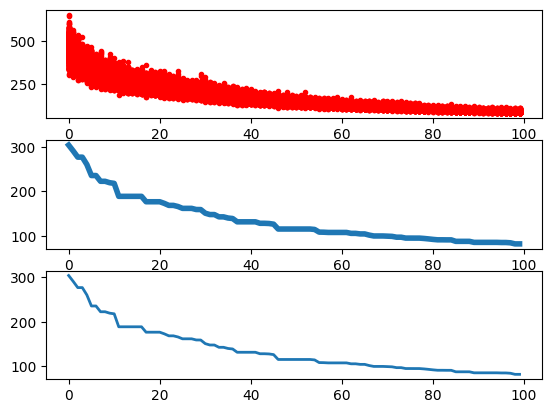

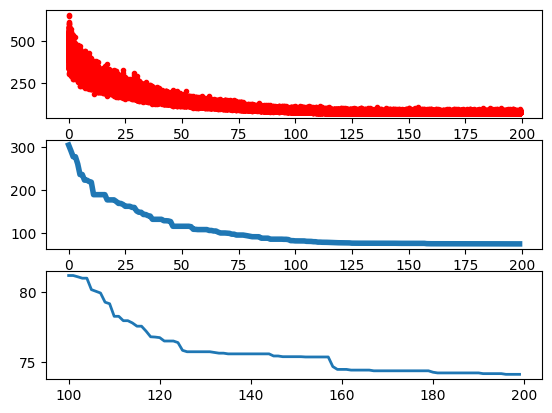

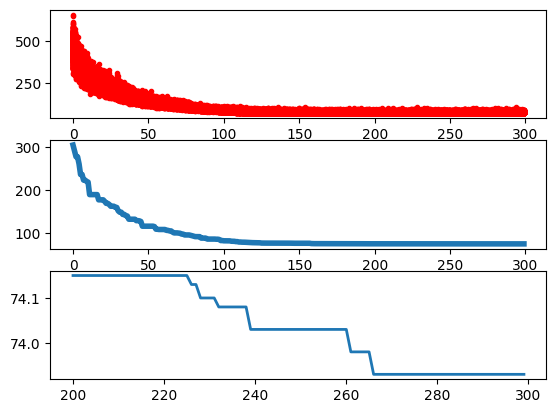

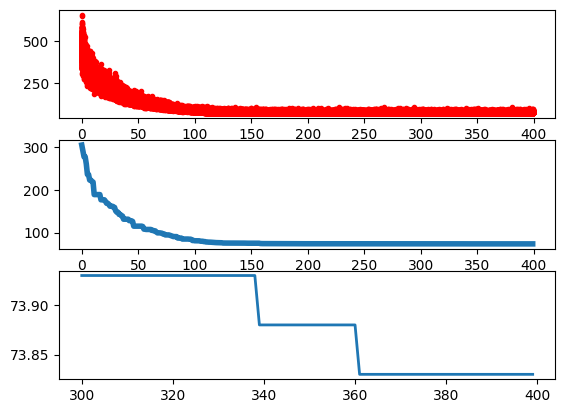

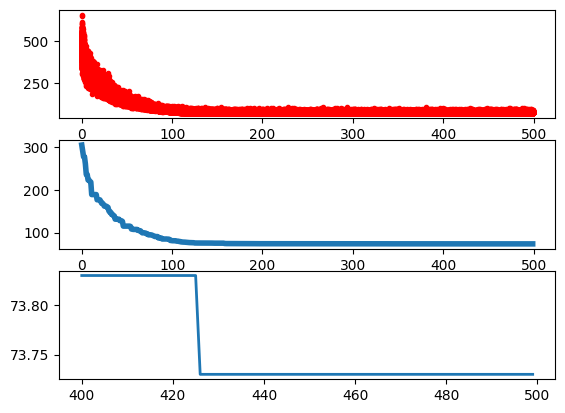

Process ForkPoolWorker-25:
Process ForkPoolWorker-32:
Process ForkPoolWorker-26:
Process ForkPoolWorker-27:
Process ForkPoolWorker-30:
Process ForkPoolWorker-28:
Process ForkPoolWorker-31:
Process ForkPoolWorker-29:
Traceback (most recent call last):


Error in callback <function flush_figures at 0x7f9d2884eaf0> (for post_execute):


Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/lib/python3.8/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
Traceback (most recent call last):
  File "/usr/lib/python3.8/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
Traceback (most recent call last):
  File "/usr/lib/python3.8/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
  File "/usr/lib/python3.8/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
  File "/usr/lib/python3.8/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
  File "/usr/lib/python3.8/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
  File "/usr/lib/python3.8/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/lib/python3.8/multiprocessing/process.py", line 315, 

KeyboardInterrupt: 

Process ForkPoolWorker-34:
Process ForkPoolWorker-39:
Process ForkPoolWorker-37:
Process ForkPoolWorker-35:
Process ForkPoolWorker-36:
Process ForkPoolWorker-38:
Process ForkPoolWorker-40:
Process ForkPoolWorker-33:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/lib/python3.8/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
  File "/usr/lib/python3.8/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/lib/python3.8/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
  File "/usr/lib/python3.8/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
  File "/usr/lib/python3.8/multiprocessing/process.py", line 315, in _bootstrap
    self.run()
  File "/usr/lib/python3.8/mu

In [21]:
#if __name__ == '__main__':

seq_list = ['_110','_110','_110']



seq_list = ['_1101_for8cargos','_1101_for8cargos','_1101_for8cargos']
seq_list = seq_list+seq_list+seq_list

rest_sequence_n = ''

rest_sequence_c = rest_sequence_n

seq_after_insert = 'CCCGACTTGCCAAAGTTGGTTAAACTTTTGAAGAGCAGCAATGAGGAGATTTTACTTAAGGCATTGCGCGCGCTCGCAGAAATCGCATCCGGCGGAAACGAGCAGATTCAAGCGGTAATTGATGCAGGAGCTCTACCAGCTCTTGTACAGCTCTTGTCGTCGCCGAATGAACAGATCTTACAAGAAGCCCTCTGGGCGTTAAGCAACATCGCGTCGGGCGGGAATGAGCAGATTCAGGCCGTAATCGACGCCGGGGCTCTTCCTGCGCTAGTACAACTGCTTAGCTCCCCTAACGAACAAATCCTGCAAGAAGCTCTCTGGGCACTGAGCAATATCGCATCTGGGGGAAACGAACAGATCCAAGCCGTGATCGATGCAGGGGCATTACCGGCCCTTGTGCAGCTCTTGAGCAGCCCAAATGAACAGATTCTCCAGGAAGCGCTTTGGGCCCTCAGTAACATCGCCAGTGGAGGTAATGAGCAGATCCAGGCAGTAATTGATGCTGGTGCTCTGCCCGCGCTGGTTCAGCTGTTGTCTTCGCCTAATGAACAAATCCTCCAAGAGGCTCTTTGGGCGCTCTCTAATATTGCAAGTGGTGGCAATGAACAGATCCAGGCCGTTATCGACGCTGGAGCGCTGCCTGCCTTGGTTCAATTATTGTCCTCTCCAAACGAACAAATCTTACAGGAAGCATTGTGGGCGTTATCCAACATTGCATCGGGTGGAAATGAGCAAATCCAAGCGGTAATCGATGCCGGAGCGTTGCCAGCGTTAGTCCAGCTGCTGAGTTCTCCCAATGAGCAAATTCTGCAGGAGGCTTTATGGGCGCTGTCAAATATTGCGTCCGGCGGCAACGAGCAAATCCAGGCGGTGATTGATGCCGGCGCCCTGCCGGCACTCGTACAGTTGCTGTCGAGCCCCAACGAGCAGATCCTTCAGGAGGCACTTTGGGCTCTGTCGAACATCGCAAGCGGAGGGAACGAGCAGATTCAAGCAGTGATTGACGCGGGAGCCCTCCCTGCACTTGTCCAGTTACTGTCCTCACCAAACGAGCAGATTTTGCAGGAAGCACTGTGGGCACTTAGTAATATCGCCGGAGGACCCACACCGTTATGGCGCGCAGAACAAATCCAAGCAGTCATCGATGCGGGTGCTTTGCCCGCCTTAGTACAATTACTTTCTTCACCGAATGAGCAGATCTTGCAAGAGGCGTTGTGGGCCCTGTCTAACATTGCGAGCGGTGGTAACGAGCAGATCCAAGCTGTAATTGACGCTGGCGCACTCCCGGCTCTCGTGCAACTCTTATCTTCCCCGAACGAACAGATTCTTCAAGAAGCATTATGGGCATTGTCCAATATTGCTGGGGGGCCAACACCACTCTGGCGTGCGGAGCAAATTCAGGCGGTCATTGACGCAGGAGCCTTACCAGCACTGGTGCAATTGTTAAGTTCGCCCAACGAACAAATTTTACAAGAGGCCTTGTGGGCTTTGTCAAACATCGCTTCCGGGGGTAACGAACAAATTCAAGCTGTTATTGATGCAGGCGCGCTTCCCGCATTAGTTCAACTTCTTTCATCCCCCAATGAACAGATTTTACAGGAAGCTTTATGGGCACTCTCGAATATCGCTGGTGGCCCCACGCCATTGTGGCGGGCGGAACAGATTCAGGCTGTGATCGACGCGGGCGCGCTGCCTGCTCTcGTACAGCTCCTTTCATCGCCCAATGAGCAGATCCTTCAAGAAGCTCTTTGGGCGTTATCTAACATTGCCAGCGGGGGAAATGAGCAGAAGCAGGCCGTAAAGGAGGCGGGAGCCCTGGAGAAACTTGAGCAGTTACAAAGCCATGAAAACGAGAAAATTCAAAAGGAAGCGCAAGAGGCCCTTGAAAAACTTCAATCTCAC'

delete_ga = False

for seq_name in seq_list:
    
    ###print out the 10 largestb object size
    
    clear_output(wait=True)
    for name, size in sorted(((name, sys.getsizeof(value)) for name, value in list(
                          locals().items())), key= lambda x: -x[1])[:10]:
        print("{:>30}: {:>8}".format(name, sizeof_fmt(size)))
    
    #seq_name = '_001'#+'+_010'+'+_011'+'+_100'+'+_101'+'+_110'+'+_111'
    input_seq = ''.join([protein_dict[i] for i in seq_name.split("+")])
    input_seq = input_seq[10:] + 'NEQIQAVIDAGALPALVQ'
    
    path = './{}_{}'.format(seq_name.replace('+', ''), nowTime)
    os.makedirs(path, exist_ok=True)
    #ga = set_run_mode(ga, 'cached')
    set_run_mode(schaffer, 'multiprocessing')
    
    
    if delete_ga:
        del ga
        del Y_history
    else:
        delete_ga = True
        

    ga = GA(func=schaffer, n_dim=len(input_seq), size_pop=100*8, max_iter=100, prob_mut=0.0015, lb=0, ub=[len(aa2codon_dict[i]) for i in input_seq], precision=int(1))



    for i in range(1, 10):
        best_x, best_y = ga.run(100)
        print(reverse_translate(best_x))
        nowTime=datetime.datetime.now().strftime('%Y_%m_%d_%H_%M')

        file = open(path + "/generation_" + str(i)+ '_'+nowTime+".txt","a")
        file.write(rest_sequence_n + reverse_translate(best_x) + rest_sequence_c)
        file.close()

        Y_history = pd.DataFrame(ga.all_history_Y)
        y_lim0 = Y_history.min(axis=1).cummin().min()
        y_lim1 = Y_history.min(axis=1).cummin().median()
        y_lim2 = Y_history.min(axis=1).cummin().quantile(0.9)
        y_lim3 = Y_history.min(axis=1).cummin().quantile(0.1)

        fig, ax = plt.subplots(3, 1)
        ax[0].plot(Y_history.index, Y_history.values, '.', color='red')
        ax[1].plot(Y_history.min(axis=1).cummin(), lw = 4)
        #ax[1].set_ylim(bottom = y_lim0, top = y_lim2)
        ax[2].plot(Y_history.min(axis=1).cummin()[-100:], lw = 2)
        #ax[2].set_ylim(bottom = y_lim0, top = y_lim3)
        #ax[2].set_xlim(left = len(Y_history.min(axis=1).cummin())*0.9, right = len(Y_history.min(axis=1).cummin()))

        plt.savefig(path + "/record_generation_{}.png".format(str(i)), dpi = 400, format = 'png')

        #ga.all_history_Y.clear()
        #ga.all_history_FitV.clear()

In [ ]:
import numpy as np
from sko.GA import GA
import time
import datetime
from sko.tools import set_run_mode


def generate_costly_function(task_type='io_costly'):
    # generate a high cost function to test all the modes
    # cost_type can be 'io_costly' or 'cpu_costly'
    if task_type == 'io_costly':
        def costly_function():
            time.sleep(0.1)
            return 1
    else:
        def costly_function():
            n = 1000000
            step1 = [np.log(i + 1) for i in range(n)]
            step2 = [np.power(i, 1.1) for i in range(n)]
            step3 = sum(step1) + sum(step2)
            return step3

    return costly_function


for task_type in ('io_costly', 'cpu_costly'):
    costly_function = generate_costly_function(task_type=task_type)


    def obj_func(p):
        costly_function()
        x1, x2 = p
        x = np.square(x1) + np.square(x2)
        return 0.5 + (np.square(np.sin(x)) - 0.5) / np.square(1 + 0.001 * x)


    for mode in ('common', 'multithreading', 'multiprocessing'):
        set_run_mode(obj_func, mode)
        ga = GA(func=obj_func, n_dim=2, size_pop=10, max_iter=5, lb=[-1, -1], ub=[1, 1], precision=1e-7)
        start_time = datetime.datetime.now()
        best_x, best_y = ga.run()
        print('on {task_type} task,use {mode} mode, costs {time_costs}s'
              .format(task_type=task_type, mode=mode,
                      time_costs=(datetime.datetime.now() - start_time).total_seconds()))

    # to use the vectorization mode, the function itself should support the mode.
    mode = 'vectorization'


    def obj_func2(p):
        costly_function()
        x1, x2 = p[:, 0], p[:, 1]
        x = np.square(x1) + np.square(x2)
        return 0.5 + (np.square(np.sin(x)) - 0.5) / np.square(1 + 0.001 * x)


    set_run_mode(obj_func2, mode)
    ga = GA(func=obj_func2, n_dim=2, size_pop=10, max_iter=5, lb=[-1, -1], ub=[1, 1], precision=1e-7)
    start_time = datetime.datetime.now()
    best_x, best_y = ga.run()
    print('on {task_type} task,use {mode} mode, costs {time_costs}s'
          .format(task_type=task_type, mode=mode,
                  time_costs=(datetime.datetime.now() - start_time).total_seconds()))

In [ ]:
from itertools import product

for bin_code in product(*[[0,1] for i in range(8)]):
    bin_code = ''.join(list(bin_code))
    print(bin_code)

In [ ]:
product([[0,1] for i in range(8)])

In [ ]:
from collections import defaultdict

def count_substring_occurrences(s):
    counts = defaultdict(int)
    for i in range(len(s)):
        for j in range(i + 15, len(s) + 1):
            counts[s[i:j]] += 1
    result = {k:v for k, v in counts.items() if len(k) > 15}
    return result


In [ ]:
AbMT = 'MSGKACTGDCKSDPCKCGANCQCGEGCTCASCKSTKACTGDCKSDPCKCGDNCQCGEGCTCASCKSTKACTGDCKSDPCKCGDNCQCGVGCTCASCKSTKACTGDCKSDPCKCGDNCQCGEGCTCASCKNTKACTGDCKSDPCKCGDNCQCGEGCTCASCKSTKACTGDCKSDPCKCGDNCQCGVGCTCASCKNTKACTGDCKSDPCKCGANCQCGEGCTCASCKSTKACTGDCKSDPCKCGDNCQCGEGCTCASCKNTKACTGDCKSDPCKCGDNCQCGDGCTCASCKTCKCTNEGCKCGQECTGPATCKCASGCSCK'
McMT = 'MSSANPACTAECKKVPCNCGDTCRCGDGCTCQTCKRDACTADCKKTPCNCGDKCGCAKGCKCQTCKRDACTAECKKTPCNCGDKCKCAKGCNCQTCKRDACTPECKKTPCNCGDKCGCADGCECQTCKRDACTADCKKTPCNCGDKCGCAKGCKCQTCKRDACTAECKKTPCNCGDKCGCADGCECQTCKRDACTAECKKTPCNCGDRCRCVHGCRCQSCSAPCKCRGTCQCGVGCTGATSCKCSRQCSCK'

In [ ]:
count_dict = count_substring_occurrences(AbMT+ 'X'*14+ McMT)

repeat_fragment_list = []
for (string, value) in count_dict.items():
    if (value>1)&(string[0]== 'C')&(string[-1]=='C')&(len(string)>30):
        print(string, value)
        repeat_fragment_list.append(string)

repeat_fragment_list = sorted(repeat_fragment_list, key=len)
repeat_fragment_filter = []
while len(repeat_fragment_list) !=0:
    frag = repeat_fragment_list.pop(0)
    keep_frag = True
    
    for repeat_fragment in repeat_fragment_list:
        if frag in repeat_fragment:
            keep_frag = False
    
    if keep_frag == True:
        repeat_fragment_filter.append(frag)
    
print(repeat_fragment_filter)

In [ ]:
for i in repeat_fragment_filter:
    print(len(i))

In [ ]:
for (string, value) in count_dict.items():
    if (value>2)&(string[0]== 'C')&(string[-1]=='C'):
        print(string, value)

In [ ]:
len('CQCGEGCTCASCKSTKACTGDCKSDPCKCGDNCQC')

In [ ]:
CQCGEGCTCASCKSTKACTGDCKSDPCKCGDNC
CGEGCTCASCKSTKACTGDCKSDPCKCGDNCQC
CTCASCKSTKACTGDCKSDPCKCGDNCQCGEGC
CASCKSTKACTGDCKSDPCKCGDNCQCGEGCTC
CKSTKACTGDCKSDPCKCGDNCQCGEGCTCASC


In [ ]:
import re

def generate_mask(string, substrings):
    mask = [0] * len(string)  # initialize mask with zeros
    for substring in substrings:
        i = 0  # start index for pattern matching
        while True:
            match = re.search(substring, string[i:])  # search for substring in remaining string
            if not match:
                break  # no more matches found, exit loop
            start_index = i + match.start()  # get start index of match
            end_index = i + match.end()  # get end index of match
            for j in range(start_index, end_index):
                mask[j] += 1  # increment mask value for overlapping region
            i = end_index  # update start index for next pattern matching
    return mask


In [ ]:
count_dict1 = count_substring_occurrences(AbMT)
count_dict2 = count_substring_occurrences(McMT)

seq_list1 = list(count_dict1.keys())
seq_list2 = list(count_dict2.keys())
seq_list = list(set(seq_list1+seq_list2))
seq_list = [i for i in seq_list if (i[0] == 'C' and i[-1] == 'C' and len(i)<70)]

mask1 = generate_mask(AbMT, seq_list)
mask2 = generate_mask(McMT, seq_list)
print(mask1.count(0)+mask2.count(0))


In [ ]:
from itertools import combinations

for ele_num in range(8,11):
    best_comb_num = len(AbMT+McMT)
    best_comb_list = []
    
    for combination in combinations(seq_list, ele_num):
        mask1 = generate_mask(AbMT, combination)
        mask2 = generate_mask(McMT, combination)
        zero_count = mask1.count(0)+mask2.count(0)
        
        if zero_count == best_comb_num:
            """
            best_comb_list_len = sum([len(i) for i in best_comb_list])
            current_comb_list_len = sum([len(i) for i in combination])
            if current_comb_list_len <best_comb_list_len:
                best_comb_num = zero_count
                best_comb_list = combination
            """
            best_comb_list.append(combination)
        
        if zero_count < best_comb_num:
            best_comb_num = zero_count
            best_comb_list = [combination]
            
    print(best_comb_num, best_comb_list)

In [ ]:
best_comb_list = []
for ele_num in range(0,20):
    best_comb_num = len(AbMT+McMT)
    
    
    for comb in combinations(seq_list, 1):
        
        combination = best_comb_list+list(comb)
        mask1 = generate_mask(AbMT, combination)
        mask2 = generate_mask(McMT, combination)
        zero_count = mask1.count(0)+mask2.count(0)
        
        
        if zero_count < best_comb_num:
            best_comb_num = zero_count
            best_comb = list(comb)
    
    best_comb_list = best_comb_list + best_comb
            
    print(ele_num,best_comb_num, best_comb_list)